# 01 Spike sorting EDA

Synthetic waveform clusters and ISI quality checks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(7)

In [2]:
# Three synthetic single-unit templates
n_waveforms = 900
n_samples = 45
t = np.linspace(-1.0, 1.0, n_samples)

def template(scale, shift):
    return -scale * np.exp(-((t - shift) ** 2) / 0.04) + 0.25 * scale * np.exp(-((t - (shift + 0.2)) ** 2) / 0.08)

base = np.vstack([
    template(1.0, -0.05),
    template(0.75, 0.0),
    template(0.55, 0.08),
])
labels = np.repeat(np.arange(3), n_waveforms // 3)
waveforms = base[labels] + 0.07 * rng.normal(size=(n_waveforms, n_samples))

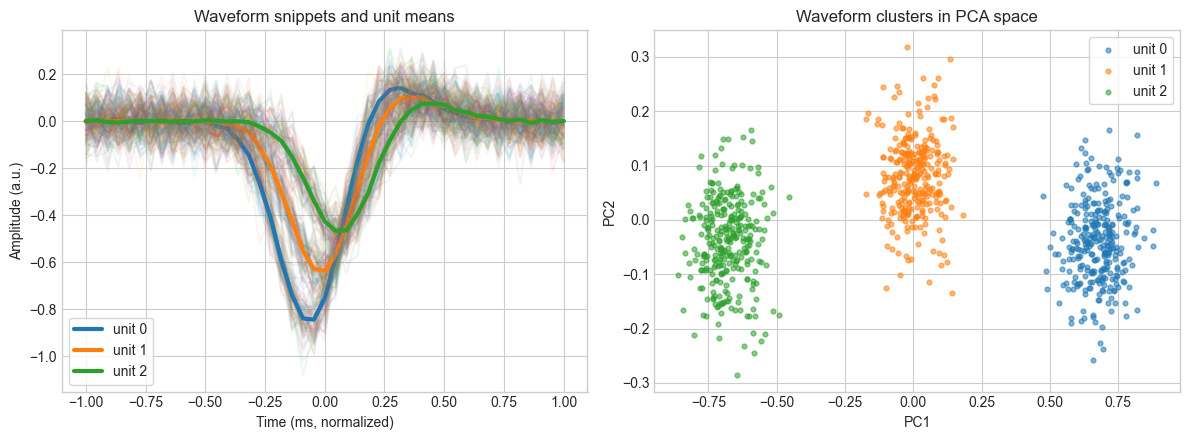

In [3]:
# PCA projection of waveforms
pca = PCA(n_components=2, random_state=0)
proj = pca.fit_transform(waveforms)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for unit in range(3):
    ax[0].plot(t, waveforms[labels == unit][:80].T, alpha=0.08)
    ax[0].plot(t, waveforms[labels == unit].mean(axis=0), linewidth=3, label=f'unit {unit}')
ax[0].set_title('Waveform snippets and unit means')
ax[0].set_xlabel('Time (ms, normalized)')
ax[0].set_ylabel('Amplitude (a.u.)')
ax[0].legend(frameon=True)

for unit in range(3):
    pts = proj[labels == unit]
    ax[1].scatter(pts[:, 0], pts[:, 1], s=12, alpha=0.55, label=f'unit {unit}')
ax[1].set_title('Waveform clusters in PCA space')
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2')
ax[1].legend(frameon=True)

fig.tight_layout()

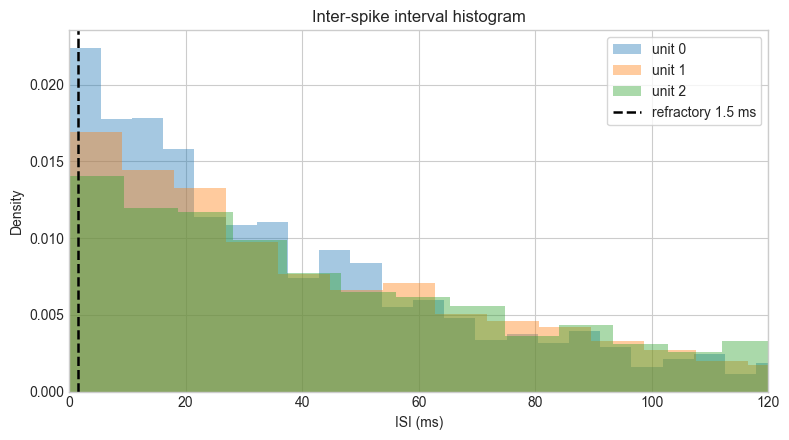

In [4]:
# ISI distributions for each unit
fig, ax = plt.subplots(figsize=(8, 4.5))
for unit in range(3):
    n_spikes = 2000
    spikes = np.cumsum(rng.exponential(scale=0.045 + 0.01 * unit, size=n_spikes))
    isi_ms = np.diff(spikes) * 1000
    ax.hist(isi_ms, bins=60, alpha=0.4, density=True, label=f'unit {unit}')

ax.axvline(1.5, color='k', linestyle='--', linewidth=1.8, label='refractory 1.5 ms')
ax.set_xlim(0, 120)
ax.set_title('Inter-spike interval histogram')
ax.set_xlabel('ISI (ms)')
ax.set_ylabel('Density')
ax.legend(frameon=True)
fig.tight_layout()